# 03 — Quantum Clustering Prototype (UBCF)

Phase 3 (user-based quantum):
- Amplitude/angle encoding of user latent vectors
- Swap-Test-inspired fidelity kernel
- Lloyd-style adiabatic/hybrid clustering on kernel distances
- MDS visualization for user geometry

Output: `quantum_user_labels.npy`

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import MDS
from sklearn.preprocessing import normalize

try:
    from qiskit.quantum_info import Statevector
    QISKIT_AVAILABLE = True
except Exception:
    QISKIT_AVAILABLE = False

try:
    import pennylane as qml
    PENNYLANE_AVAILABLE = True
except Exception:
    PENNYLANE_AVAILABLE = False

IN_DIR = Path("data/processed_32m_ubcf")
OUT_DIR = Path("data/processed_32m_ubcf")

SEED = 42
N_QUBITS = 5
TARGET_DIM = 2 ** N_QUBITS
SAMPLE_USERS = 300
K_QUANTUM = 6
MAX_ITERS = 12

user_latent_full = np.load(IN_DIR / "user_latent.npy").astype(np.float32)
rng = np.random.default_rng(SEED)
sample_idx = np.sort(rng.choice(np.arange(len(user_latent_full)), size=min(SAMPLE_USERS, len(user_latent_full)), replace=False))
X = user_latent_full[sample_idx]

if X.shape[1] < TARGET_DIM:
    X = np.pad(X, ((0, 0), (0, TARGET_DIM - X.shape[1])), mode="constant")
else:
    X = X[:, :TARGET_DIM]

X_amp = normalize(X, norm="l2", axis=1).astype(np.float32)
X_ang = X[:, :N_QUBITS]
X_ang = ((X_ang - X_ang.min(axis=0, keepdims=True)) / (X_ang.ptp(axis=0, keepdims=True) + 1e-8)) * np.pi

print(f"Qiskit={QISKIT_AVAILABLE} PennyLane={PENNYLANE_AVAILABLE} sample={len(X)}")

C:\Users\acolumban\AppData\Local\Temp\ipykernel_28108\476250547.py:9: DeprecationWarning: Using Qiskit with Python 3.9 is deprecated as of the 2.1.0 release. Support for running Qiskit with Python 3.9 will be removed in the 2.3.0 release, which coincides with when Python 3.9 goes end of life.
  from qiskit.quantum_info import Statevector


Qiskit=True PennyLane=True sample=300


In [2]:
# Swap-Test-inspired fidelity kernel (state overlap proxy)
def angle_state(theta_vec):
    state = np.array([1.0 + 0j], dtype=np.complex64)
    for t in theta_vec:
        qubit = np.array([np.cos(t / 2.0), np.sin(t / 2.0)], dtype=np.complex64)
        state = np.kron(state, qubit)
    return state

def amp_state(v):
    v = v.astype(np.complex64)
    return v / (np.linalg.norm(v) + 1e-12)

def swap_fidelity(a, b):
    # Swap-test success relation: p0 = (1 + |<a|b>|^2)/2
    overlap2 = float(np.abs(np.vdot(a, b)) ** 2)
    return overlap2

amp_states = [amp_state(X_amp[i]) for i in range(len(X_amp))]
ang_states = [angle_state(X_ang[i]) for i in range(len(X_ang))]

n = len(X_amp)
kernel = np.zeros((n, n), dtype=np.float32)
for i in range(n):
    kernel[i, i] = 1.0
    for j in range(i + 1, n):
        k = 0.5 * (swap_fidelity(amp_states[i], amp_states[j]) + swap_fidelity(ang_states[i], ang_states[j]))
        kernel[i, j] = k
        kernel[j, i] = k

np.savez_compressed(IN_DIR / "user_kernel_matrix.npz", kernel=kernel, sample_idx=sample_idx)
print(kernel.shape)

(300, 300)


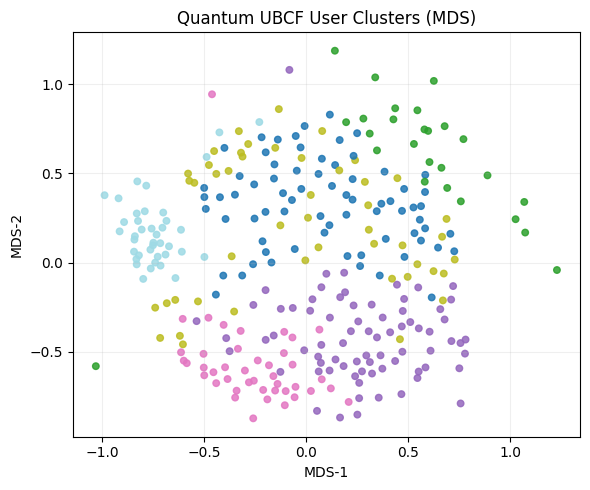

Saved: quantum_user_labels.npy and user_kernel_matrix.npz


In [3]:
# Lloyd-style kernel clustering
def quantum_lloyd(kernel_mat, k=6, max_iters=10, seed=42):
    rng_local = np.random.default_rng(seed)
    n_points = kernel_mat.shape[0]
    centers = rng_local.choice(n_points, size=min(k, n_points), replace=False)
    labels = np.zeros(n_points, dtype=np.int32)

    for _ in range(max_iters):
        prev = labels.copy()
        d2 = np.zeros((n_points, len(centers)), dtype=np.float32)
        diag = np.diag(kernel_mat)
        for c, ci in enumerate(centers):
            d2[:, c] = diag + kernel_mat[ci, ci] - 2.0 * kernel_mat[:, ci]
        labels = np.argmin(d2, axis=1).astype(np.int32)

        new_centers = centers.copy()
        for c in range(len(centers)):
            members = np.where(labels == c)[0]
            if len(members) == 0:
                continue
            sub = kernel_mat[np.ix_(members, members)]
            medoid_local = int(np.argmax(sub.mean(axis=1)))
            new_centers[c] = int(members[medoid_local])
        centers = new_centers
        if np.array_equal(prev, labels):
            break

    return labels

quantum_user_labels = quantum_lloyd(kernel, k=K_QUANTUM, max_iters=MAX_ITERS, seed=SEED)
np.save(OUT_DIR / "quantum_user_labels.npy", quantum_user_labels)

# MDS visualization
dmat = np.sqrt(np.clip(np.diag(kernel)[:, None] + np.diag(kernel)[None, :] - 2 * kernel, 0, None))
mds = MDS(n_components=2, dissimilarity="precomputed", random_state=SEED)
xy = mds.fit_transform(dmat)

plt.figure(figsize=(6, 5))
plt.scatter(xy[:, 0], xy[:, 1], c=quantum_user_labels, s=22, cmap="tab20", alpha=0.85)
plt.title("Quantum UBCF User Clusters (MDS)")
plt.xlabel("MDS-1")
plt.ylabel("MDS-2")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print("Saved: quantum_user_labels.npy and user_kernel_matrix.npz")